# NBI Query Performance Analysis
## Benchmarking 4 Different Tools on Parquet Data

This notebook analyzes the performance of different query tools on NBI parquet data:
- **DuckDB**: SQL queries with minimal memory overhead
- **Pandas**: In-memory operations (fastest for small datasets)
- **Polars**: Lazy evaluation with eager loading
- **PyArrow**: Columnar compute library

**Dataset**: 1,728 parquet files (~1.4 GB)
**Column tested**: STATE_CODE_001 (consistent across all files)

⚠️ **IMPORTANT: Performance Metrics Disclaimer**

These benchmarks are based on **RAW, UNCLEANED** NBI dataset. Performance results may vary significantly under different conditions:

1. **Data Quality Impact**: Results use uncleaned data with type inconsistencies and missing values. Production-grade cleaned data may show different performance characteristics.

2. **Query Type Dependency**: Performance winners differ by query complexity:
   - Simple queries (1 column, basic aggregation): **Pandas dominates** (0.547s)
   - Complex queries (12+ columns, multi-level aggregation): **DuckDB dominates** (2.257s)
   - Query selectivity and filter effectiveness significantly affect optimization benefits

3. **Dataset-Specific Results**: Benchmarks measured on:
   - 1,728 parquet files (~1.4 GB)
   - 21.6M total rows
   - Mixed type columns (some requiring schema casting)
   - Results may not generalize to other datasets

4. **Optimization Strategy Differences**: Each tool's performance depends on its optimization approach:
   - **DuckDB**: SQL query planner + predicate pushdown (best for complex queries)
   - **Polars**: Lazy evaluation for deferred execution
   - **PyArrow**: Dataset API with filter pushdown
   - **Pandas**: Eager evaluation only (best for simple in-memory operations)

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# Style settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
colors = {'DuckDB': '#0066CC', 'Pandas': '#FF6B35', 'Polars': '#004E89', 'PyArrow': '#1AC8ED'}

In [2]:
# Load benchmark results
results_file = Path('scripts/query_analysis/benchmark_results.json')

if results_file.exists():
    with open(results_file) as f:
        results = json.load(f)
    print(f"✓ Loaded results from {results_file}")
else:
    print(f"✗ Results file not found. Please run: python scripts/query_analysis/benchmark_summary.py")
    print(f"Expected location: {results_file.absolute()}")

✓ Loaded results from scripts\query_analysis\benchmark_results.json


In [3]:
# Prepare data for visualization
tools = list(results.keys())
queries = list(results['duckdb'].keys())

# Create comparison dataframe
data = []
for tool in tools:
    for query in queries:
        avg_time = results[tool][query].get('avg')
        if avg_time is not None:
            data.append({
                'Tool': tool.capitalize(),
                'Query': query,
                'Time (s)': avg_time
            })

df = pd.DataFrame(data)
print(f"Comparison data ready: {len(df)} records")
df.head(10)

Comparison data ready: 12 records


,Tool,Query,Time (s)
0,Duckdb,Q1: Count by State,1.235259
1,Duckdb,Q2: Filter & Count,1.210367
2,Duckdb,Q3: Aggregate HAVING,1.200272
3,Polars,Q1: Count by State,4.215969
4,Polars,Q2: Filter & Count,4.138459
5,Polars,Q3: Aggregate HAVING,4.099550
6,Pandas,Q1: Count by State,0.553694
7,Pandas,Q2: Filter & Count,0.615471
8,Pandas,Q3: Aggregate HAVING,0.518809
9,Pyarrow,Q1: Count by State,23.794226


## 1. Query-by-Query Comparison

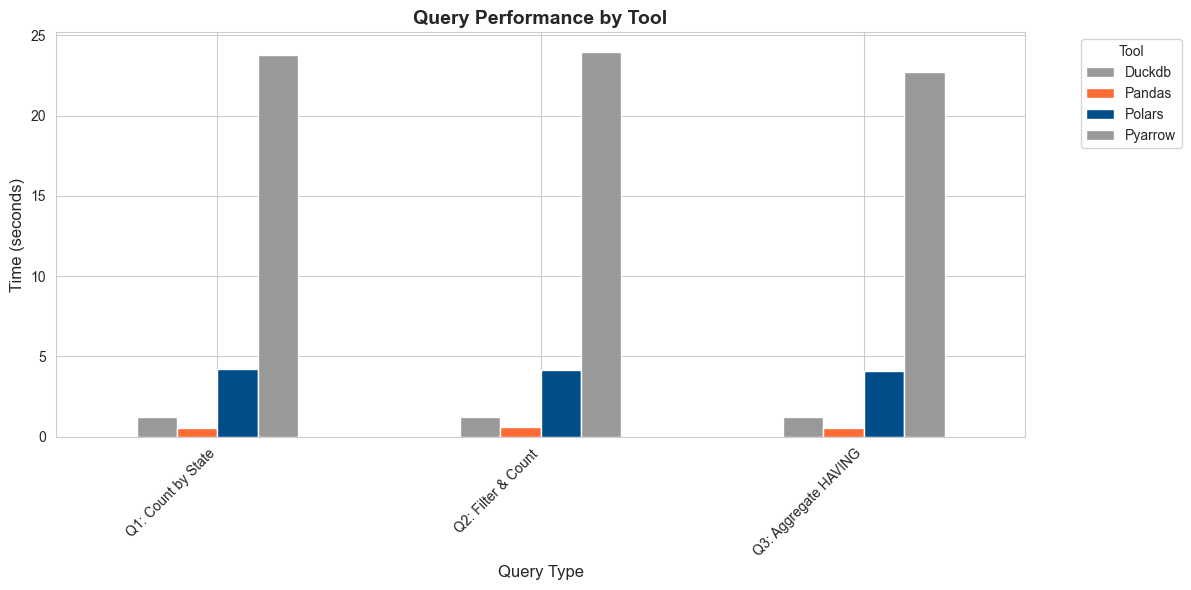


Query Performance Table:
Tool                  Duckdb  Pandas  Polars  Pyarrow
Query                                                
Q1: Count by State     1.235   0.554   4.216   23.794
Q2: Filter & Count     1.210   0.615   4.138   23.990
Q3: Aggregate HAVING   1.200   0.519   4.100   22.727


In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

# Bar chart comparing tools for each query
query_comparison = df.pivot(index='Query', columns='Tool', values='Time (s)')
query_comparison.plot(kind='bar', ax=ax, color=[colors.get(t, '#999') for t in query_comparison.columns])

ax.set_title('Query Performance by Tool', fontsize=14, fontweight='bold')
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_xlabel('Query Type', fontsize=12)
ax.legend(title='Tool', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nQuery Performance Table:")
print(query_comparison.round(3))

## 2. Overall Performance Ranking

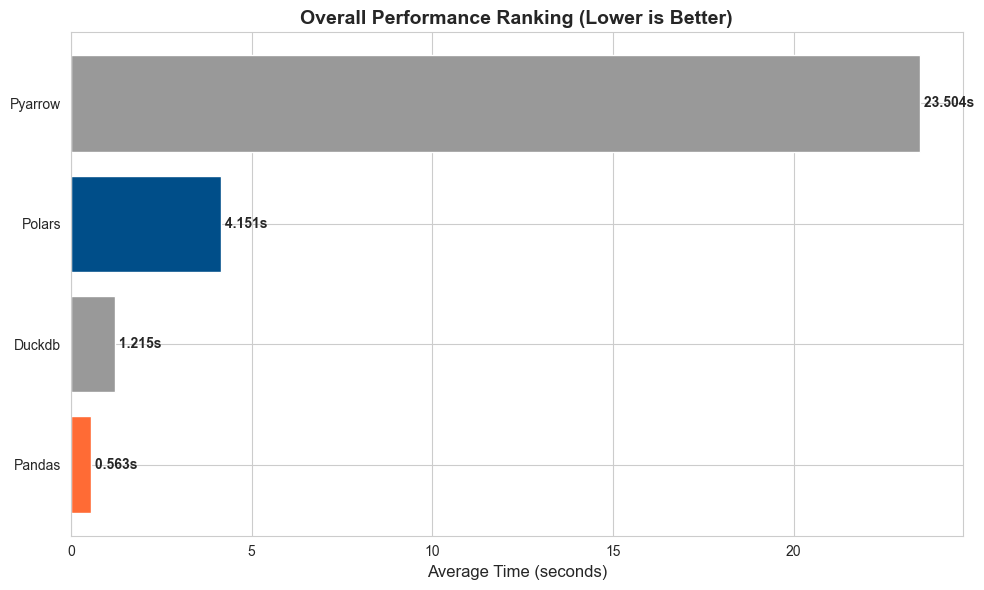


OVERALL RANKING
🥇 1. Pandas       - 0.563s avg
🥈 2. Duckdb       - 1.215s avg
🥉 3. Polars       - 4.151s avg
4️⃣ 4. Pyarrow      - 23.504s avg


In [5]:
# Calculate average time per tool
tool_averages = df.groupby('Tool')['Time (s)'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart for overall ranking
bars = ax.barh(range(len(tool_averages)), tool_averages.values, 
                color=[colors.get(t, '#999') for t in tool_averages.index])

ax.set_yticks(range(len(tool_averages)))
ax.set_yticklabels(tool_averages.index)
ax.set_xlabel('Average Time (seconds)', fontsize=12)
ax.set_title('Overall Performance Ranking (Lower is Better)', fontsize=14, fontweight='bold')

# Add value labels on bars
for i, (tool, time) in enumerate(tool_averages.items()):
    ax.text(time, i, f' {time:.3f}s', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("OVERALL RANKING")
print("="*50)
for rank, (tool, time) in enumerate(tool_averages.items(), 1):
    medal = ['🥇', '🥈', '🥉', '4️⃣'][rank-1]
    print(f"{medal} {rank}. {tool:12s} - {time:.3f}s avg")
print("="*50)